In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import yaml

from imblearn.under_sampling import RandomUnderSampler

from src.evaluate.evaluate import evaluate_model

Load config

In [2]:
with open("../configs/baseline_config.yaml") as f:
    config = yaml.safe_load(f)

print(config)

{'data_csv': '../data/preprocessed/Event_occurrence_matrix.csv', 'random_forest': {'n_estimators': 100, 'max_depth': None, 'random_state': 42, 'class_weight': 'balanced', 'n_jobs': -1}, 'test_size': 0.2, 'stratify': True}


Load data

In [3]:
df = pd.read_csv(config['data_csv'], index_col=0)

X = df.drop(columns=['Label', 'Type']).values
y = df['Label'].values

Split data

In [4]:
stratify = y if config['stratify'] else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config['test_size'],
    random_state=config['random_forest']['random_state'],
    stratify=stratify
)

In [5]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print("After undersampling:", pd.Series(y_res).value_counts().to_dict())

After undersampling: {'Fail': 13470, 'Success': 13470}


Train Random Forest

In [6]:
rf_params = config['random_forest']
rf_classifier = RandomForestClassifier(
    n_estimators=rf_params['n_estimators'],
    max_depth=rf_params['max_depth'],
    random_state=rf_params['random_state'],
    class_weight=rf_params['class_weight'],
    n_jobs=rf_params['n_jobs'],
    verbose=1
)
# rf_classifier.fit(X_train, y_train)
rf_classifier.fit(X_res, y_res)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate

In [7]:
y_pred = rf_classifier.predict(X_test)
y_proba = rf_classifier.predict_proba(X_test)[:,1]

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


Classification Report:
              precision    recall  f1-score   support

        Fail     0.9953    1.0000    0.9976      3368
     Success     1.0000    0.9999    0.9999    111645

    accuracy                         0.9999    115013
   macro avg     0.9976    0.9999    0.9988    115013
weighted avg     0.9999    0.9999    0.9999    115013



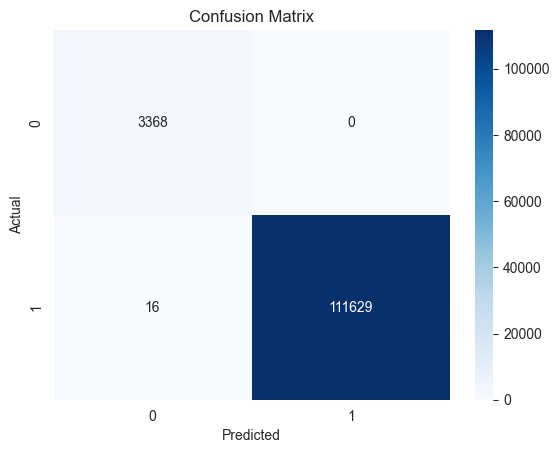

ROC-AUC: 0.99997221294081


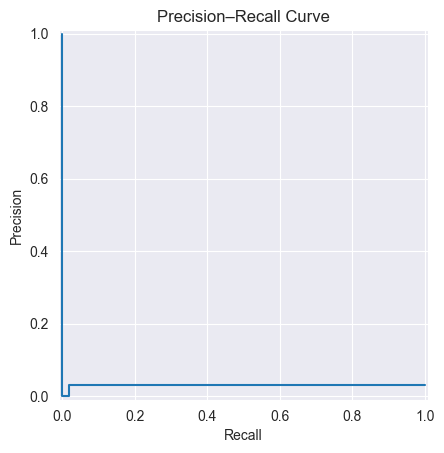

PR-AUC: 0.028733963512135894


In [8]:
evaluate_model(y_test, y_pred, y_proba)

In [9]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_proba, pos_label="Fail")
print("PR-AUC:", ap)

PR-AUC: 0.028733963512135894


ROC-AUC is misleading under extreme class imbalance because the false positive rate remains small even with many false alarms, whereas PR-AUC correctly penalizes false positives and reflects real anomaly detection performance.

In [10]:
importances = rf_classifier.feature_importances_

feat_imp = pd.DataFrame({
    "feature": range(X.shape[1]),
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(10)

,feature,importance
19,19,0.328609
25,25,0.135642
26,26,0.081027
4,4,0.076114
8,8,0.070080
10,10,0.059225
12,12,0.045721
27,27,0.044183
20,20,0.038187
24,24,0.036274
